# Homework 3

## Consegna

 ### 1. Regressione lineare semplice polinomiale

Dati $(xi, yi), i = 1, . . . n$ approssimare i dati mediante un modello dato
dalla funzione polinomiale:

$$
f(x, \alpha) = \sum_{k=0}^d a_k x^k,
$$

Scrivere un codice python che risolve il problema dei minimi quadrati
lineari.

$$
\min || X\alpha - y ||_2^2
$$

secondo le notazioni utilizzate a lezione (X è la matrice di Vandermonde)
con la fattorizzazione SVD.


Inclusione librerie

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

Creazione del problema test

In [9]:
def problem_1(n, d, sigma  = 0.1, alpha = None):
    # --- 2. Creazione del vettore alpha (coefficienti) ---
    # Il testo dice "un vettore alpha", ne scegliamo uno arbitrario di lunghezza d+1
    if alpha is None:
        alpha = np.random.randn(d + 1)

    # --- 3. Generazione di n valori x_i equispaziati in [0, 1] ---
    x = np.linspace(0, 1, n)

    # --- 4. Definizione della funzione polinomiale f(x, alpha) ---
    def f_poly(x, coefficients):
        y = np.zeros_like(x)
        for k, a_k in enumerate(coefficients):
            y += a_k * (x ** k)
        return y

    # --- 5. Generazione del rumore e ---
    # Richiesta: np.random.normal(loc=0, scale=sigma, size=...)
    # Nota: size deve essere n per avere un errore per ogni punto x_i
    e = np.random.normal(loc=0, scale=sigma, size=n)

    # --- 6. Generazione dei valori y_i ---
    # Formula: y_i = f(x_i, alpha) + e_i
    y = f_poly(x, alpha) + e
    return x, y, alpha, f_poly

Test del codice precedente

In [10]:
def plot(n = 50, d_approx = 3, alpha = None):
    x, y, alpha, f_poly = problem_1(n, d_approx, sigma=0.1, alpha=alpha)
    print(f"Grado d: {d_approx}")
    print(f"Coefficienti alpha: {alpha}")
    print(f"Primi 5 valori di x: {x[:5]}")
    print(f"Primi 5 valori di y: {y[:5]}")

    plt.scatter(x, y, color='red', label='Dati rumorosi $y_i$', s=15)
    plt.plot(x, f_poly(x, alpha), color='blue', label='Polinomio vero $f(x, \\alpha)$', alpha=0.5)
    plt.legend()
    plt.title(f"Problema Test (d={d_approx}, $\\sigma$=0.1)")
    plt.show()


Grado d: 10
Coefficienti alpha: [ 0.5 -1.2  2.5  1. ]
Primi 5 valori di x: [0.         0.02040816 0.04081633 0.06122449 0.08163265]
Primi 5 valori di y: [0.63511457 0.71100598 0.45644274 0.46087269 0.47280733]


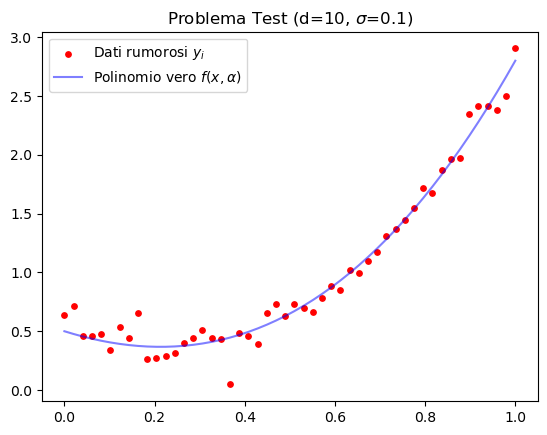

Grado d: 1
Coefficienti alpha: [0.75196702 0.27825724]
Primi 5 valori di x: [0.         0.02564103 0.05128205 0.07692308 0.1025641 ]
Primi 5 valori di y: [0.70331049 0.70041515 0.92771057 0.59588632 0.84556371]


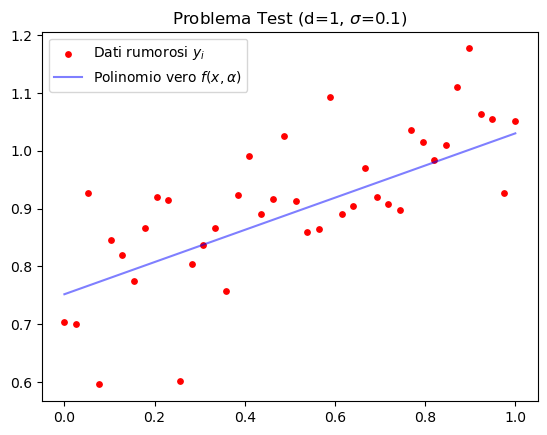

Grado d: 3
Coefficienti alpha: [-1.49101297  0.00196758 -0.44929745 -0.32686694]
Primi 5 valori di x: [0.         0.02564103 0.05128205 0.07692308 0.1025641 ]
Primi 5 valori di y: [-1.59744535 -1.59317763 -1.43028854 -1.45246975 -1.35508937]


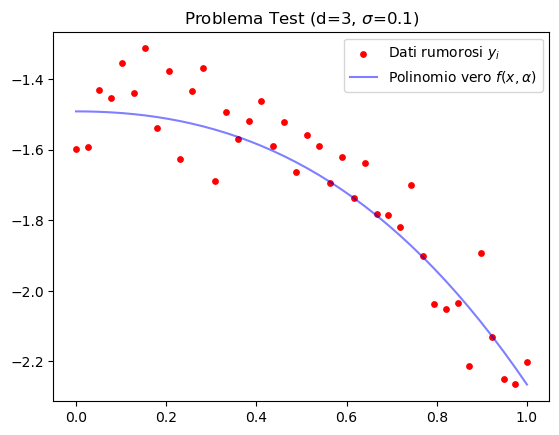

Grado d: 12
Coefficienti alpha: [ 0.67651699 -0.51646168 -0.12958475  1.07541006  1.78780493 -0.81326477
 -1.26354148  0.33736503  0.78006565  1.40253642  0.58466064 -1.11955794
 -0.77863567]
Primi 5 valori di x: [0.         0.07142857 0.14285714 0.21428571 0.28571429]
Primi 5 valori di y: [0.67710902 0.52057333 0.69859449 0.65832856 0.62754173]


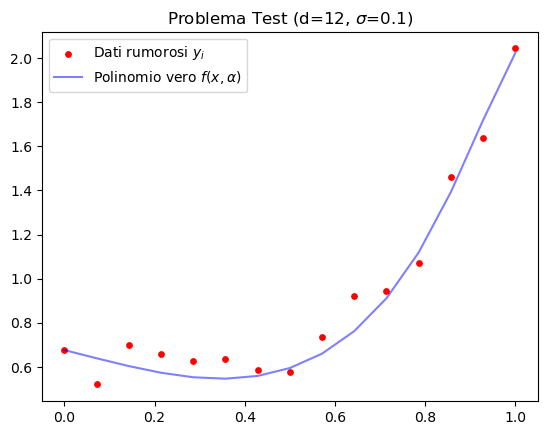

In [11]:
plot(50, 10, alpha = np.array([0.5, -1.2, 2.5, 1.0]))  # Fit Corretto con alpha fisso
plot(40, 1)  # Underfit (d=1, Reale=3)
plot(40, 3)  # Fit Corretto (d=3, Reale=3)
plot(15, 12)  # Overfit (d=12, Reale=3, Punti=15)

--- Analisi Dataset: submission.csv ---
Numero campioni: 1459
Grado d=1 -> MSE: 6.0837e+09
Grado d=3 -> MSE: 6.0464e+09
Grado d=5 -> MSE: 6.0349e+09
Grado d=15 -> MSE: 4.7923e+09
Grado d=100 -> MSE: 4.4951e+09


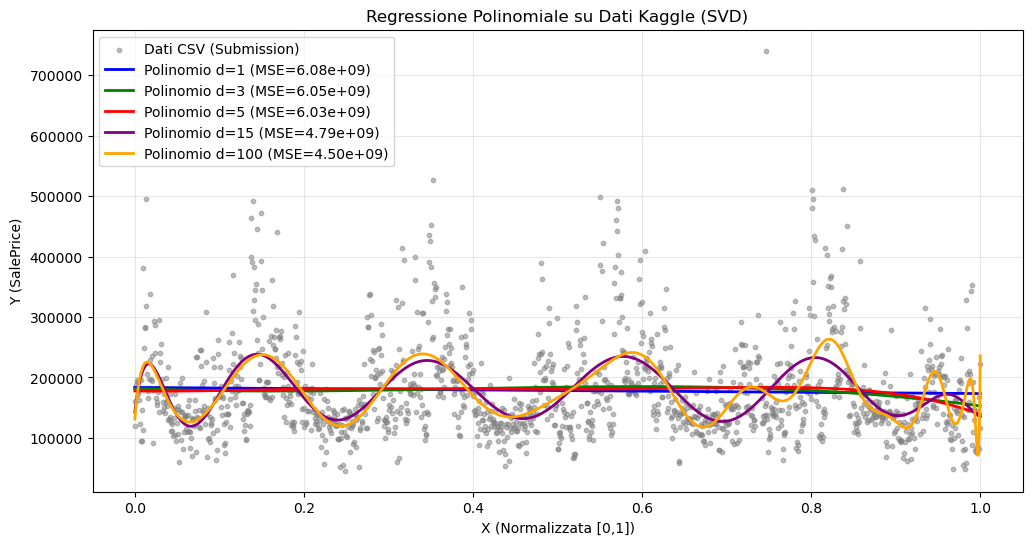

In [12]:


def build_vandermonde(x, d):
    return np.vander(x, N=d + 1, increasing=True)

def solve_ls_svd(X, y):
    # 1. SVD: X = U * S * Vt
    # scipy.linalg.svd è spesso più efficiente di numpy.linalg.svd
    U, s, Vt = sp.linalg.svd(X, full_matrices=False)
    
    # 2. Inversione dei valori singolari (1/s_i)
    # Gestione valori vicini a zero per stabilità numerica
    threshold = 1e-12
    s_inv = np.zeros_like(s)
    mask = s > threshold
    s_inv[mask] = 1.0 / s[mask]
    
    # 3. Calcolo della soluzione: alpha = V * S_inv * U.T * y
    # Nota: Vt restituito da scipy è già trasposto (V^T)
    # U.T @ y -> Proiezione di y su U
    uty = U.T @ y
    # s_inv * ... -> Scaling per l'inversa dei valori singolari
    s_uty = s_inv * uty
    # Vt.T @ ... -> Proiezione nello spazio dei coefficienti (Vt.T = V)
    alpha = Vt.T @ s_uty
    
    return alpha

def poly_eval(x, alpha):
    d = len(alpha) - 1
    X = build_vandermonde(x, d)
    return X @ alpha

# --- FUNZIONI DI SUPPORTO DATI ---

def load_and_normalize_csv(csv_path):
    """Carica e normalizza i dati dal CSV (necessario per stabilità SVD)."""
    df = pd.read_csv(csv_path)
    
    # Estrazione colonne (assumiamo col 0 = X, col 1 = Y)
    x_raw = df.iloc[:, 0].values.astype(float)
    y_raw = df.iloc[:, 1].values.astype(float)
    
    # Ordinamento per plotting corretto
    sort_idx = np.argsort(x_raw)
    x_sorted = x_raw[sort_idx]
    y_sorted = y_raw[sort_idx]
    
    # Normalizzazione x in [0, 1]
    x_min, x_max = np.min(x_sorted), np.max(x_sorted)
    x_norm = (x_sorted - x_min) / (x_max - x_min)
    
    return x_norm, y_sorted, x_raw

# --- FUNZIONE PRINCIPALE DI TEST ---

def analyze_csv_regression(csv_path, degrees_to_test):
    """
    Esegue la regressione polinomiale su un file CSV per diversi gradi
    e visualizza i risultati.
    """
    # 1. Caricamento Dati
    x, y, x_original = load_and_normalize_csv(csv_path)
    
    plt.figure(figsize=(12, 6))
    
    # Plot dei dati originali (scatter)
    # Usiamo x normalizzata per il plot per coerenza con il fit
    plt.scatter(x, y, color='gray', alpha=0.5, s=10, label='Dati CSV (Submission)')
    
    colors = ['blue', 'green', 'red', 'purple', 'orange']
    
    print(f"--- Analisi Dataset: {csv_path} ---")
    print(f"Numero campioni: {len(x)}")
    
    # 2. Loop sui gradi richiesti
    for i, d in enumerate(degrees_to_test):
        # A. Costruzione matrice Vandermonde
        X_mat = build_vandermonde(x, d)
        
        # B. Risoluzione SVD
        alpha = solve_ls_svd(X_mat, y)
        
        # C. Calcolo predizione
        y_pred = poly_eval(x, alpha)
        
        # D. Calcolo Errore (MSE)
        mse = np.mean((y - y_pred)**2)
        print(f"Grado d={d} -> MSE: {mse:.4e}")
        
        # E. Plotting curva
        color = colors[i % len(colors)]
        plt.plot(x, y_pred, color=color, linewidth=2, label=f'Polinomio d={d} (MSE={mse:.2e})')

    plt.title("Regressione Polinomiale su Dati Kaggle (SVD)")
    plt.xlabel("X (Normalizzata [0,1])")
    plt.ylabel("Y (SalePrice)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- ESECUZIONE DEL TEST ---

# Specifica qui il nome del file caricato
file_name = "submission.csv"

# Testiamo con gradi diversi per vedere underfit (d=1) e potenziali fit migliori
# Nota: d=15 potrebbe oscillare molto (fenomeno di Runge o overfitting su rumore)
analyze_csv_regression(file_name, degrees_to_test=[1, 3, 5, 15, 100])



 ### 2. Regressione lineare multipla

Scrivere un codice python per realizzare una regressione lineare multipla
utilizzando le funzioni della libreria Pandas e scikit-learn.



Librerie aggiuntive

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


Funzioni richieste


--- REGRESSIONE LINEARE MULTIPLA ---
Dataset: kc_house_data_NaN.csv | Shape: (21597, 21) | Target: price

[Modello Completo] R2: 0.6914 | MSE: 40144359438.3941

--- Ablation Study (Importanza Features) ---
Feature                   | Delta R2  
----------------------------------------
Unnamed: 0                | 0.00036
id                        | -0.00026
bedrooms                  | 0.00336
bathrooms                 | 0.00201
sqft_living               | 0.00000
sqft_lot                  | 0.00024
floors                    | -0.00009
waterfront                | 0.01696
view                      | 0.01015
condition                 | 0.00081
grade                     | 0.02533
sqft_above                | 0.00000
sqft_basement             | 0.00000
yr_built                  | 0.01587
yr_renovated              | 0.00048
zipcode                   | 0.00559
lat                       | 0.05324
long                      | 0.00454
sqft_living15             | -0.00026
sqft_lot15                

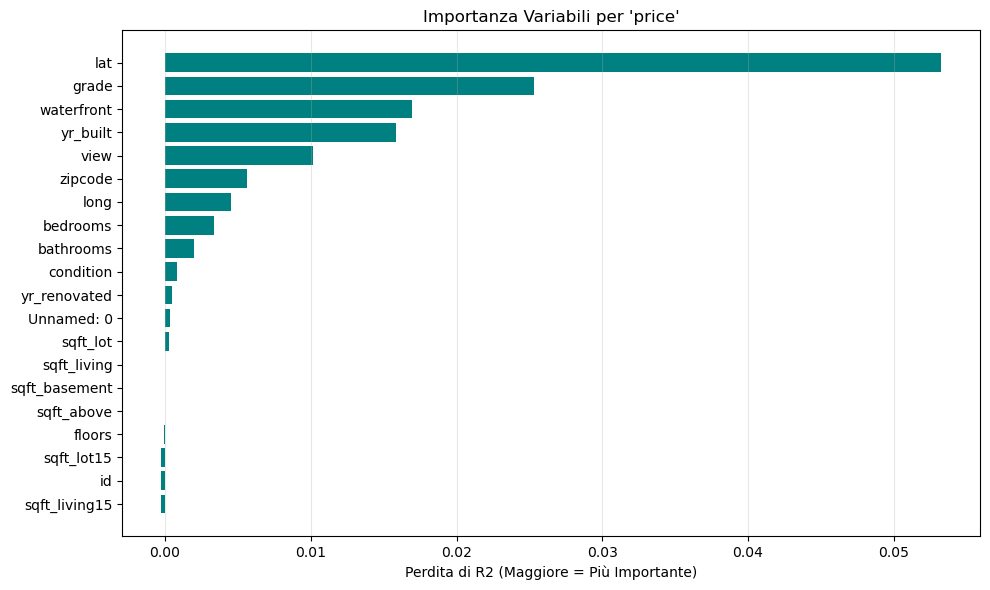

In [14]:
def run_multiple_regression_analysis():
    print("\n--- REGRESSIONE LINEARE MULTIPLA ---")

    # 1. Caricamento e Pulizia
    # Assumiamo che il file esista e sia nella cartella corretta
    filename = "kc_house_data_NaN.csv"
    df = pd.read_csv(filename)
    
    # Pulizia essenziale: solo numeri e niente NaN (necessario per evitare errori di calcolo)
    df = df.select_dtypes(include=[np.number]).dropna()
    
    # 2. Definizione Target e Features
    # Cerca una colonna che si chiama 'price' (o simile), altrimenti usa l'ultima
    target_col = next((c for c in df.columns if c.lower() == 'price'), df.columns[-1])
    
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    print(f"Dataset: {filename} | Shape: {df.shape} | Target: {target_col}")

    # 3. Split Training/Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Regressione Completa
    model_full = LinearRegression()
    model_full.fit(X_train, y_train)
    y_pred_full = model_full.predict(X_test)
    
    r2_full = r2_score(y_test, y_pred_full)
    mse_full = mean_squared_error(y_test, y_pred_full)
    
    print(f"\n[Modello Completo] R2: {r2_full:.4f} | MSE: {mse_full:.4f}")

    # 5. Feature Importance (Ablation Study)
    print("\n--- Ablation Study (Importanza Features) ---")
    print(f"{'Feature':<25} | {'Delta R2':<10}")
    print("-" * 40)
    
    results = []
    
    for feature in X.columns:
        # Addestramento modello ridotto (senza la feature corrente)
        model_sub = LinearRegression()
        model_sub.fit(X_train.drop(columns=[feature]), y_train)
        
        # Valutazione diretta con .score (che calcola R2)
        r2_sub = model_sub.score(X_test.drop(columns=[feature]), y_test)
        
        # Delta R2: quanto perdo togliendo la feature?
        delta_r2 = r2_full - r2_sub
        results.append((feature, delta_r2))
        
        print(f"{feature:<25} | {delta_r2:.5f}")

    # 6. Plot Risultati
    results.sort(key=lambda x: x[1], reverse=True)
    features, deltas = zip(*results)
    
    plt.figure(figsize=(10, 6))
    plt.barh(features, deltas, color='teal')
    plt.xlabel("Perdita di R2 (Maggiore = Più Importante)")
    plt.title(f"Importanza Variabili per '{target_col}'")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


run_multiple_regression_analysis()